<a href="https://colab.research.google.com/github/mennaamrr40-wq/heart-disease-prediction/blob/main/project_ML_final_final_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Important Libraries**

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import math
import missingno as msno
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.kernel_approximation import RBFSampler
from sklearn.model_selection import learning_curve
from sklearn.preprocessing import label_binarize
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_score, recall_score, roc_curve, auc
from sklearn.experimental import enable_iterative_imputer
from sklearn.model_selection import GridSearchCV
from sklearn.impute import SimpleImputer , IterativeImputer, KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import VotingClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

##**Descriptive Info On Data**

###**Reading The Data**

In [ ]:
df = pd.read_csv('dirty_v3_path.csv')
df.head()

,Age,Gender,Medical Condition,Glucose,Blood Pressure,BMI,Oxygen Saturation,LengthOfStay,Cholesterol,Triglycerides,HbA1c,Smoking,Alcohol,Physical Activity,Diet Score,Family History,Stress Level,Sleep Hours,random_notes,noise_col
0,46.0,Male,Diabetes,137.04,135.27,28.90,96.04,6,231.88,210.56,7.61,0,0,-0.20,3.54,0,5.07,6.05,lorem,-137.057211
1,22.0,Male,Healthy,71.58,113.27,26.29,97.54,2,165.57,129.41,4.91,0,0,8.12,5.90,0,5.87,7.72,ipsum,-11.230610
2,50.0,NaN,Asthma,95.24,NaN,22.53,90.31,2,214.94,165.35,5.60,0,0,5.01,4.65,1,3.09,4.82,ipsum,98.331195
3,57.0,NaN,Obesity,NaN,130.53,38.47,96.60,5,197.71,182.13,6.92,0,0,3.16,3.37,0,3.01,5.33,lorem,44.187175
4,66.0,Female,Hypertension,95.15,178.17,31.12,94.90,4,259.53,115.85,5.98,0,1,3.56,3.40,0,6.38,6.64,lorem,44.831426


###**Columns Number**

In [ ]:
df.shape

(30000, 20)

20 features and 30k rows

###**Columns Names**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                25500 non-null  float64
 1   Gender             25500 non-null  object 
 2   Medical Condition  25500 non-null  object 
 3   Glucose            25500 non-null  float64
 4   Blood Pressure     25500 non-null  float64
 5   BMI                30000 non-null  float64
 6   Oxygen Saturation  30000 non-null  float64
 7   LengthOfStay       30000 non-null  int64  
 8   Cholesterol        30000 non-null  float64
 9   Triglycerides      30000 non-null  float64
 10  HbA1c              30000 non-null  float64
 11  Smoking            30000 non-null  int64  
 12  Alcohol            30000 non-null  int64  
 13  Physical Activity  30000 non-null  float64
 14  Diet Score         30000 non-null  float64
 15  Family History     30000 non-null  int64  
 16  Stress Level       300

###**Statistics of the Columns**

In [ ]:
df.describe().round(2)

,Age,Glucose,Blood Pressure,BMI,Oxygen Saturation,LengthOfStay,Cholesterol,Triglycerides,HbA1c,Smoking,Alcohol,Physical Activity,Diet Score,Family History,Stress Level,Sleep Hours,noise_col
count,25500.00,25500.00,25500.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00
mean,54.62,123.62,140.46,28.48,94.95,4.41,213.03,176.84,6.29,0.28,0.24,3.80,4.03,0.44,5.92,6.23,-0.52
std,15.97,41.58,21.08,5.73,3.74,2.76,33.52,48.81,1.32,0.45,0.43,2.01,1.82,0.50,2.23,1.19,100.08
min,10.00,20.32,74.24,7.67,67.51,1.00,95.73,-22.48,3.28,0.00,0.00,-3.68,-1.75,0.00,-2.44,1.59,-412.17
25%,45.00,96.28,125.14,24.59,93.00,3.00,189.50,141.28,5.33,0.00,0.00,2.35,2.77,0.00,4.37,5.41,-68.27
50%,55.00,110.50,138.32,28.05,95.30,4.00,211.84,173.36,5.97,0.00,0.00,3.59,3.79,0.00,5.90,6.23,-0.51
75%,66.00,136.61,153.79,31.81,97.38,5.00,235.31,208.63,6.92,1.00,0.00,5.06,5.02,1.00,7.44,7.05,66.81
max,89.00,318.51,226.38,56.85,110.07,19.00,358.37,421.51,12.36,1.00,1.00,12.41,12.06,1.00,15.45,10.35,467.89


###**Checking for duplicates**

In [ ]:
df.duplicated().sum()

np.int64(0)

No Duplicates

###**Checking for Null**

In [ ]:
df.isna().sum()

,0
Age,4500
Gender,4500
Medical Condition,4500
Glucose,4500
Blood Pressure,4500
BMI,0
Oxygen Saturation,0
LengthOfStay,0
Cholesterol,0
Triglycerides,0


There are Null Values in: Age , Gender, Medical Condition, Glucose and Blood Pressure Variables

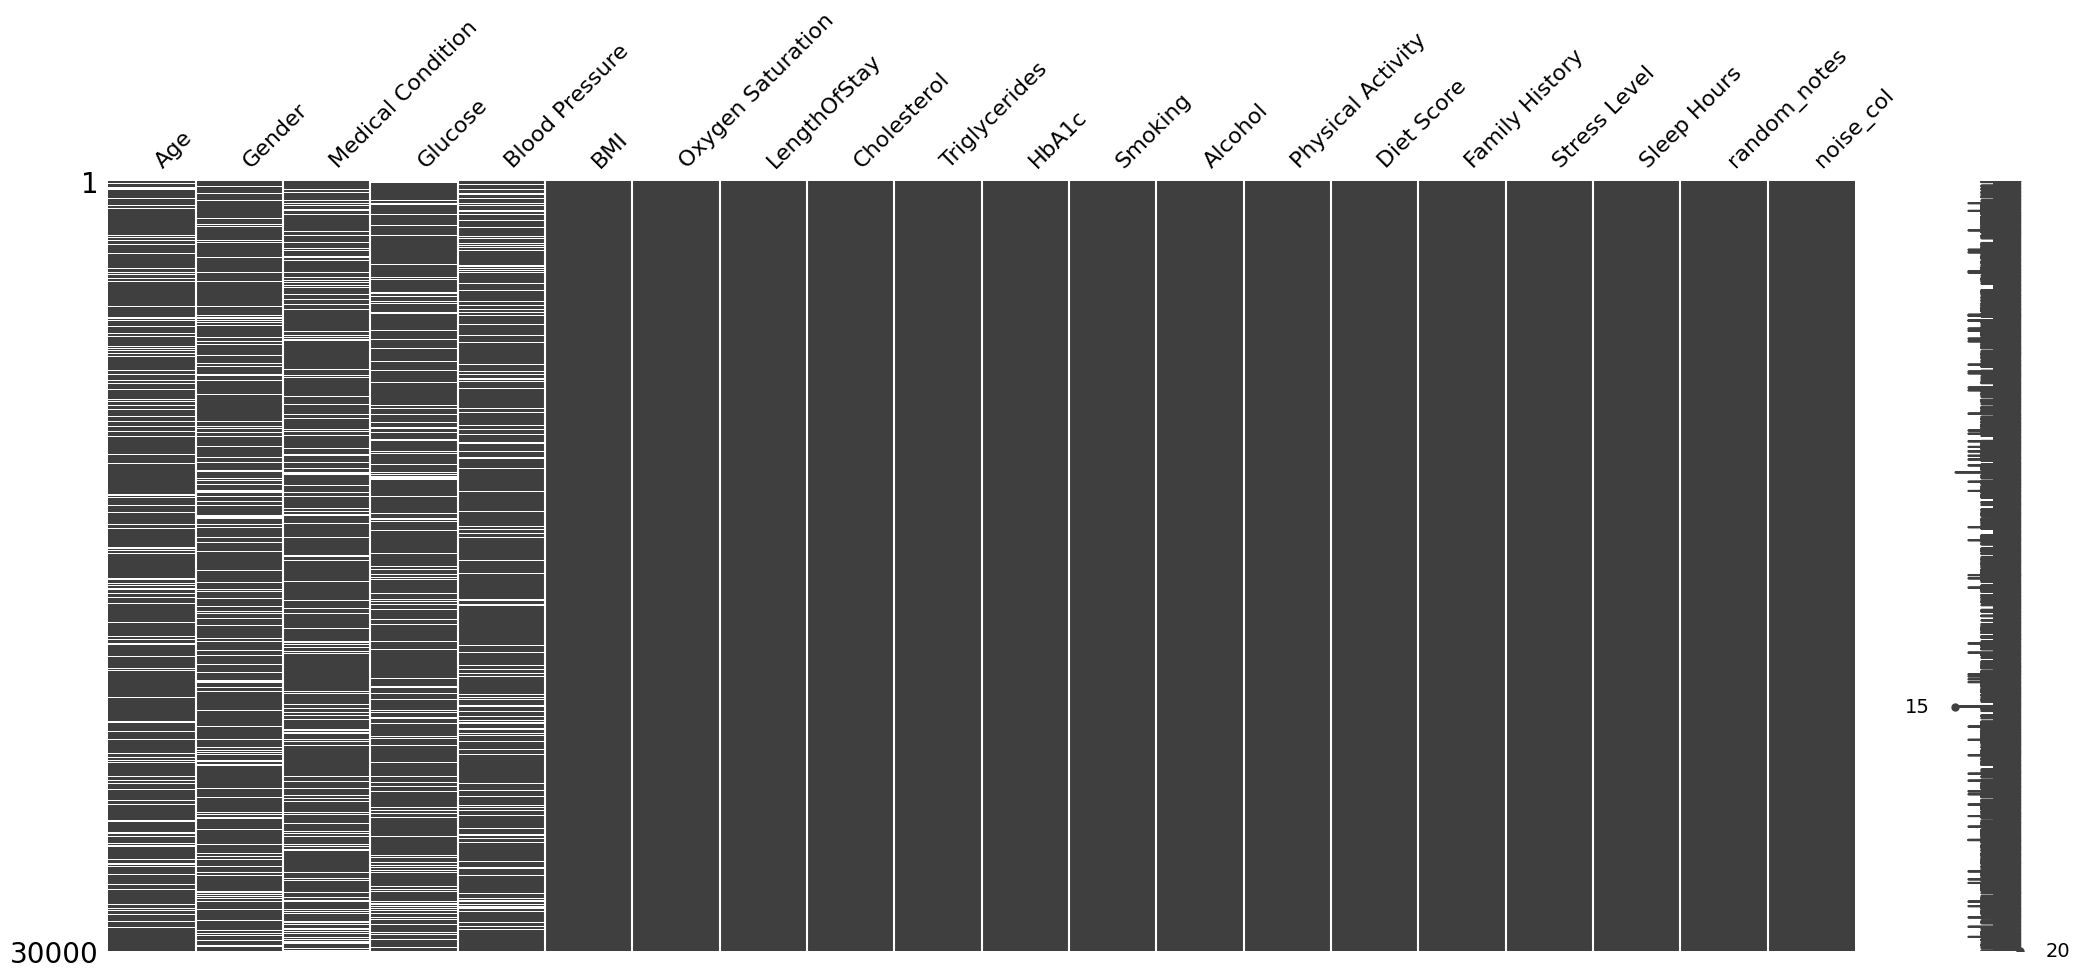

In [ ]:
msno.matrix(df)
plt.show()

##**EDA for numeric columns**

###**Numeric and catagorical variables**

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns

###**Histogram for numeric data**

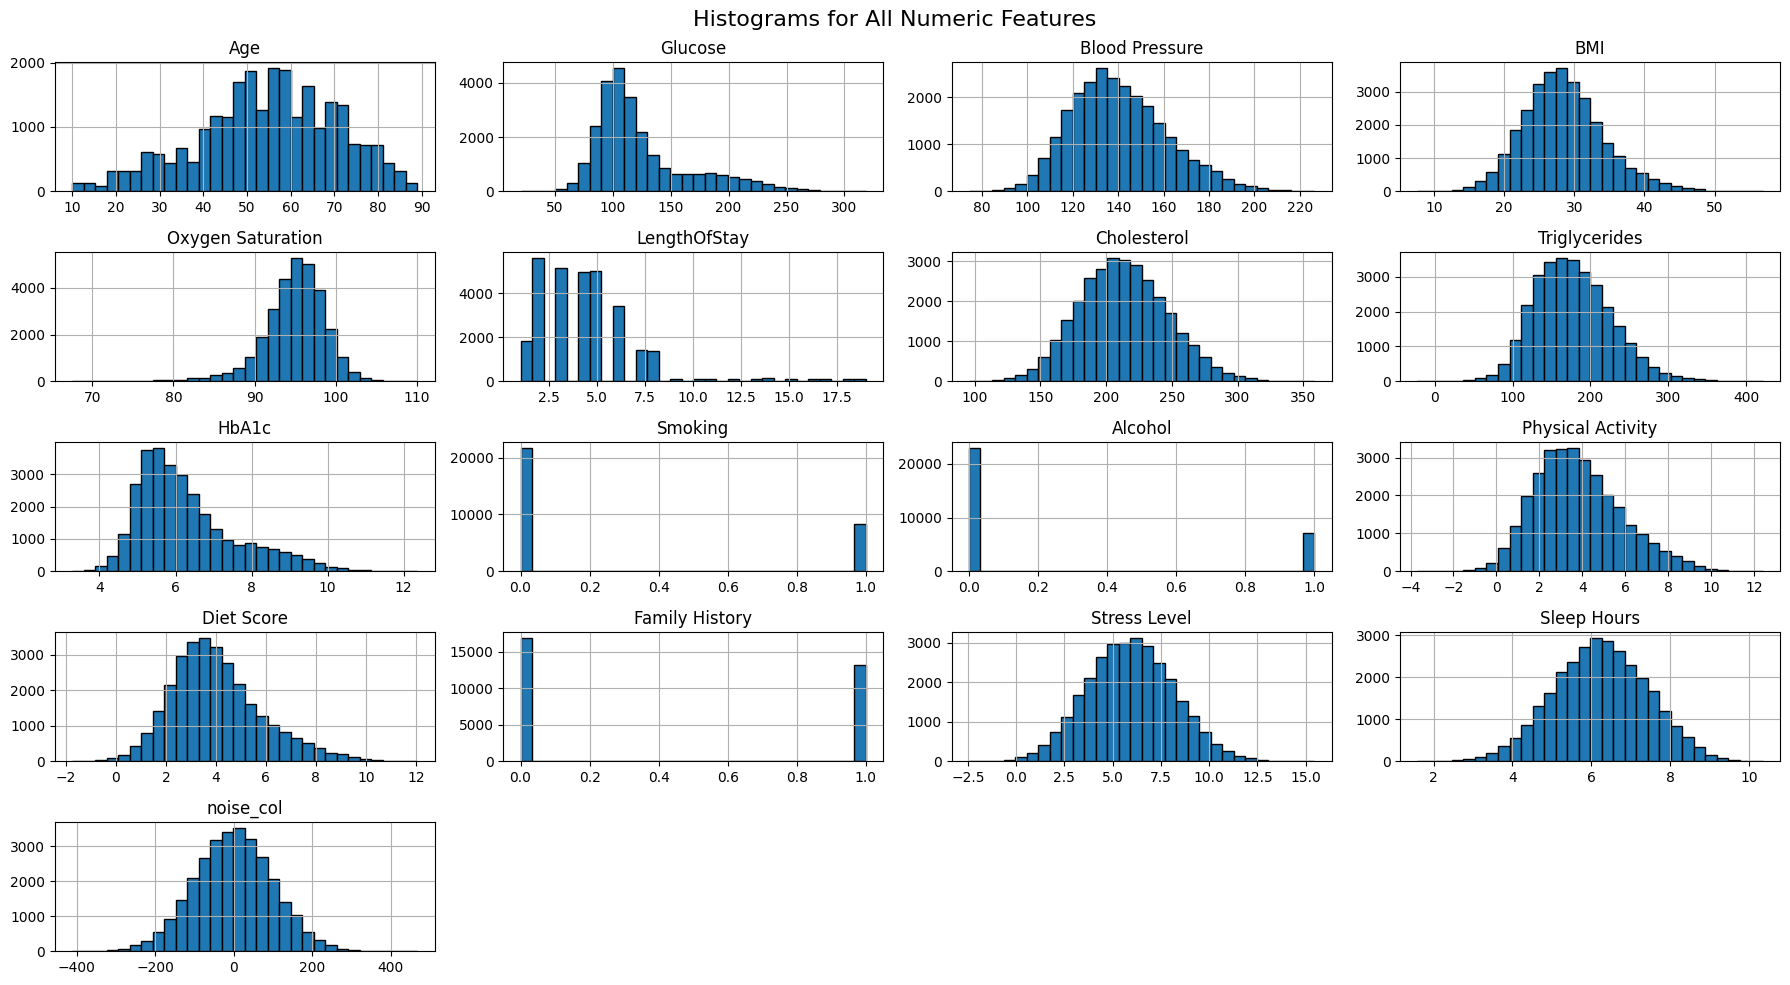

In [ ]:
df[num_cols].hist(
    bins=30,
    figsize=(18, 10),
    edgecolor='black'
)

plt.suptitle("Histograms for All Numeric Features", fontsize=16)
plt.tight_layout()
plt.show()

The distribution of the data is almost normal so no transformation is needed

###**Boxplot for numeric columns**

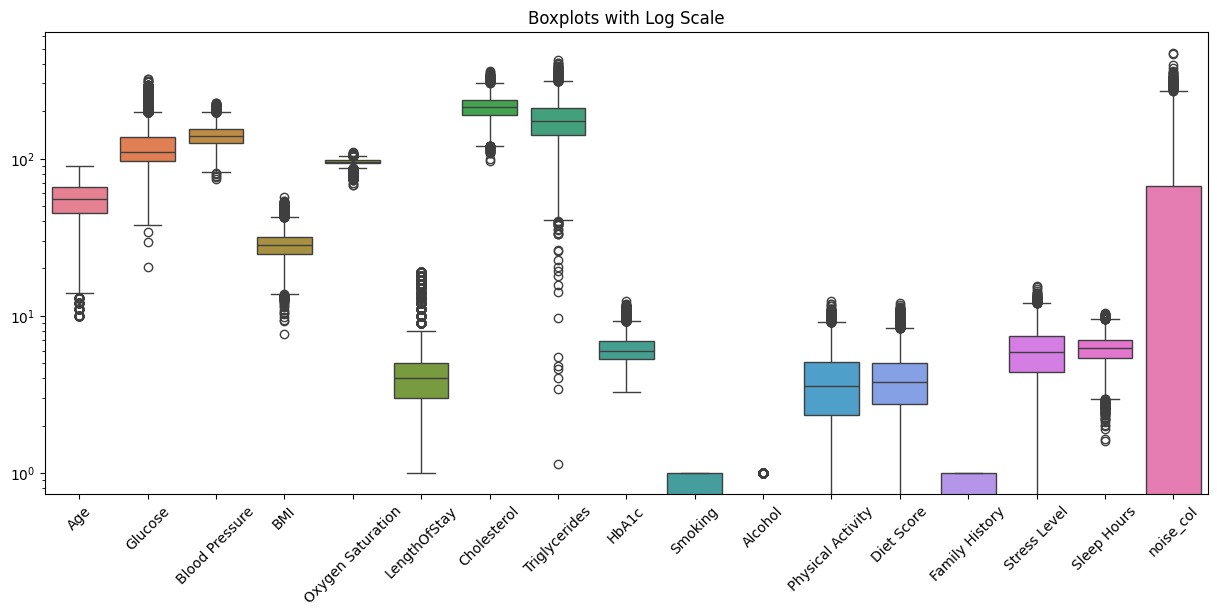

In [ ]:
plt.figure(figsize=(15,6))
sns.boxplot(data=df[num_cols])
plt.yscale('log')
plt.xticks(rotation=45)
plt.title("Boxplots with Log Scale")
plt.show()

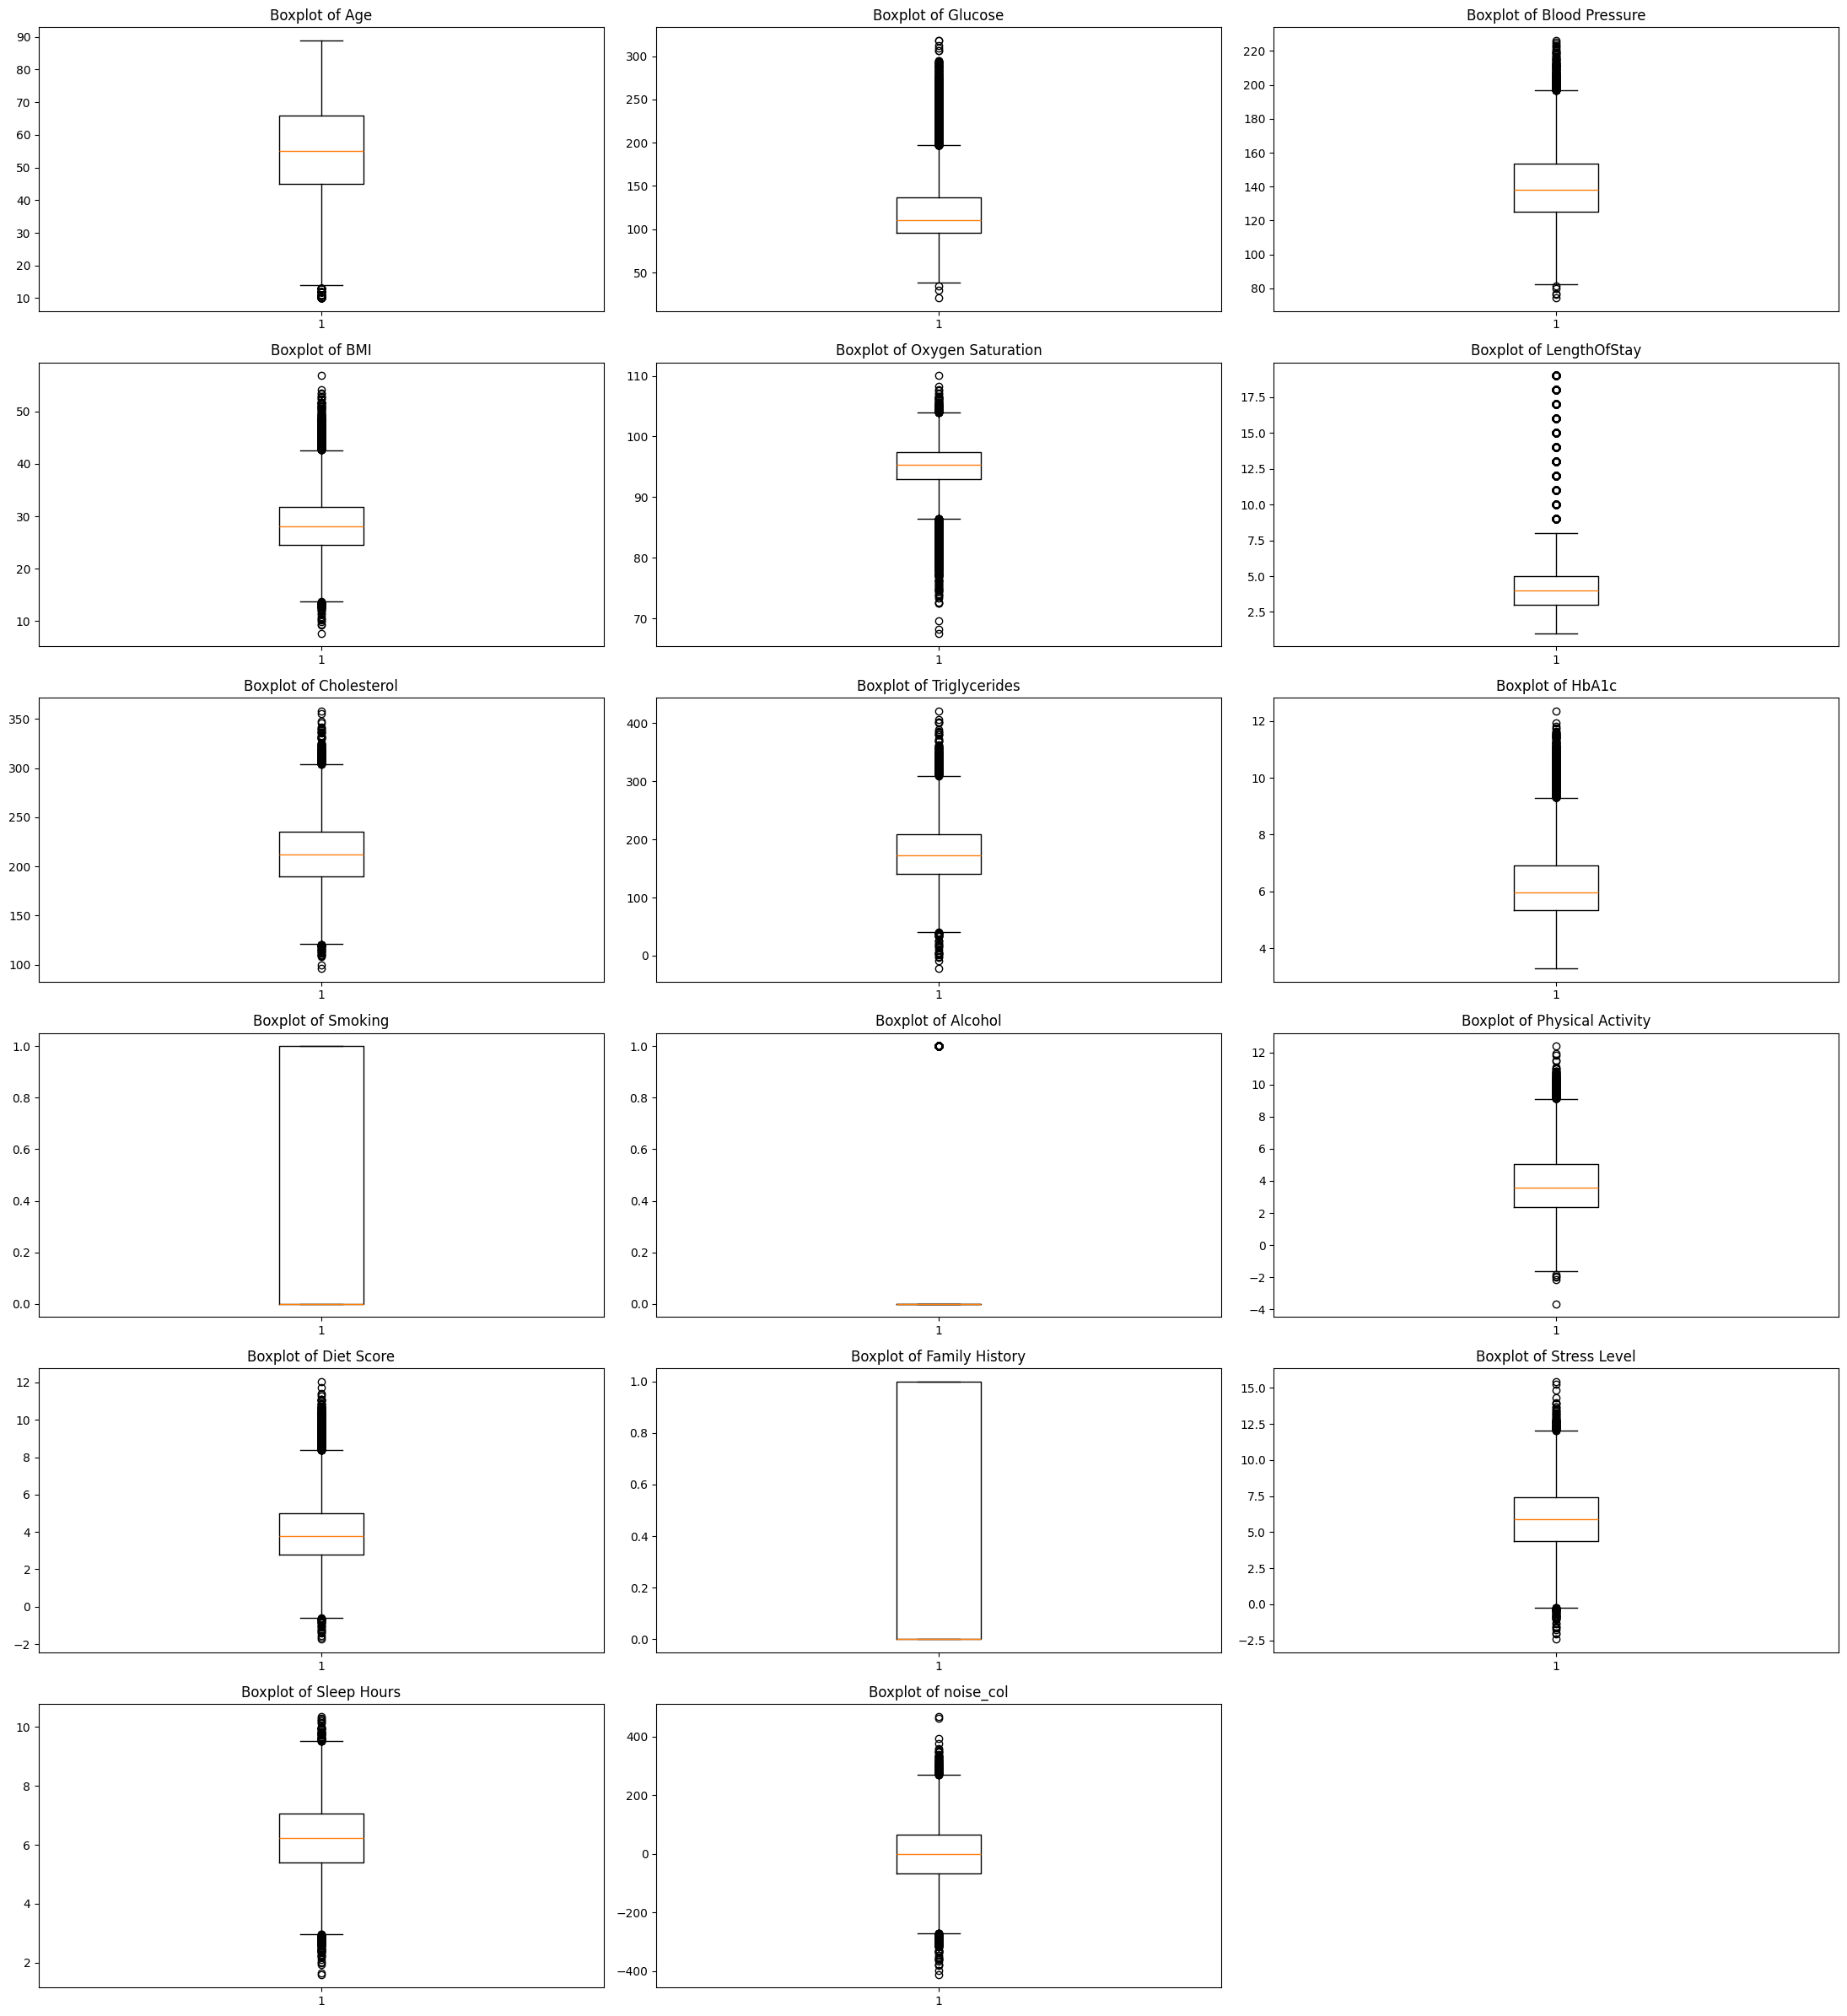

In [ ]:
n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

plt.figure(figsize=(22, n_rows * 4))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    plt.boxplot(df[col].dropna())
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

Almost every feature has outliers that need to be fixed

###**Pattern between features**

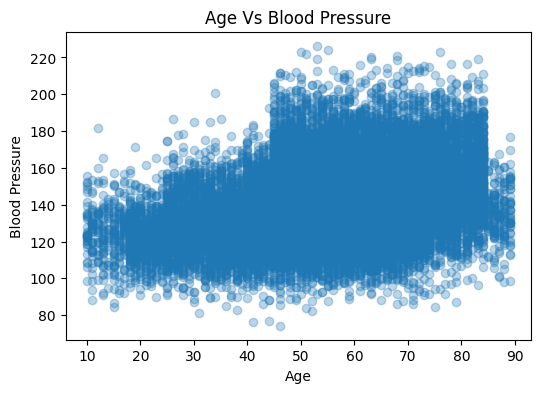

In [ ]:
plt.figure(figsize=(6, 4))
plt.scatter(df['Age'], df['Blood Pressure'], alpha=0.3)
plt.xlabel('Age')
plt.ylabel('Blood Pressure')
plt.title('Age Vs Blood Pressure')
plt.show()

This scatter plot shows the relationship between age and blood pressure.
A slight upward trend can be observed, indicating that blood pressure generally increases with age.
However, the wide spread of points suggests a weak to moderate relationship with considerable variability

/tmp/ipython-input-956097733.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_chol = df.groupby(bins)['Cholesterol'].mean()


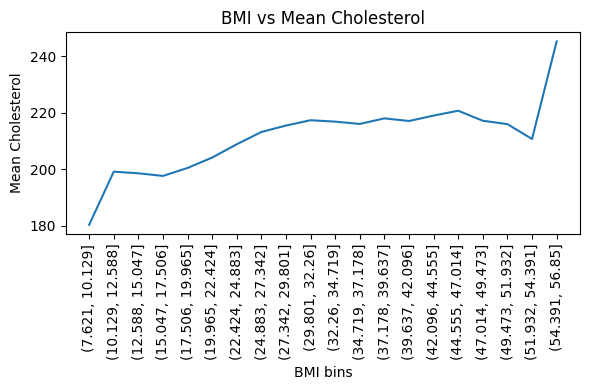

In [ ]:
bins = pd.cut(df['BMI'], bins=20)
mean_chol = df.groupby(bins)['Cholesterol'].mean()

plt.figure(figsize=(6,4))
plt.plot(mean_chol.index.astype(str), mean_chol.values)
plt.xticks(rotation=90)
plt.xlabel('BMI bins')
plt.ylabel('Mean Cholesterol')
plt.title('BMI vs Mean Cholesterol')
plt.tight_layout()
plt.show()

The plot illustrates the relationship between BMI and average cholesterol levels by grouping BMI into bins.
An overall increasing trend is observed, indicating that higher BMI values are generally associated with higher mean cholesterol levels.
This suggests a positive relationship between BMI and cholesterol.

In [ ]:
corr_matrix = df[num_cols].corr()

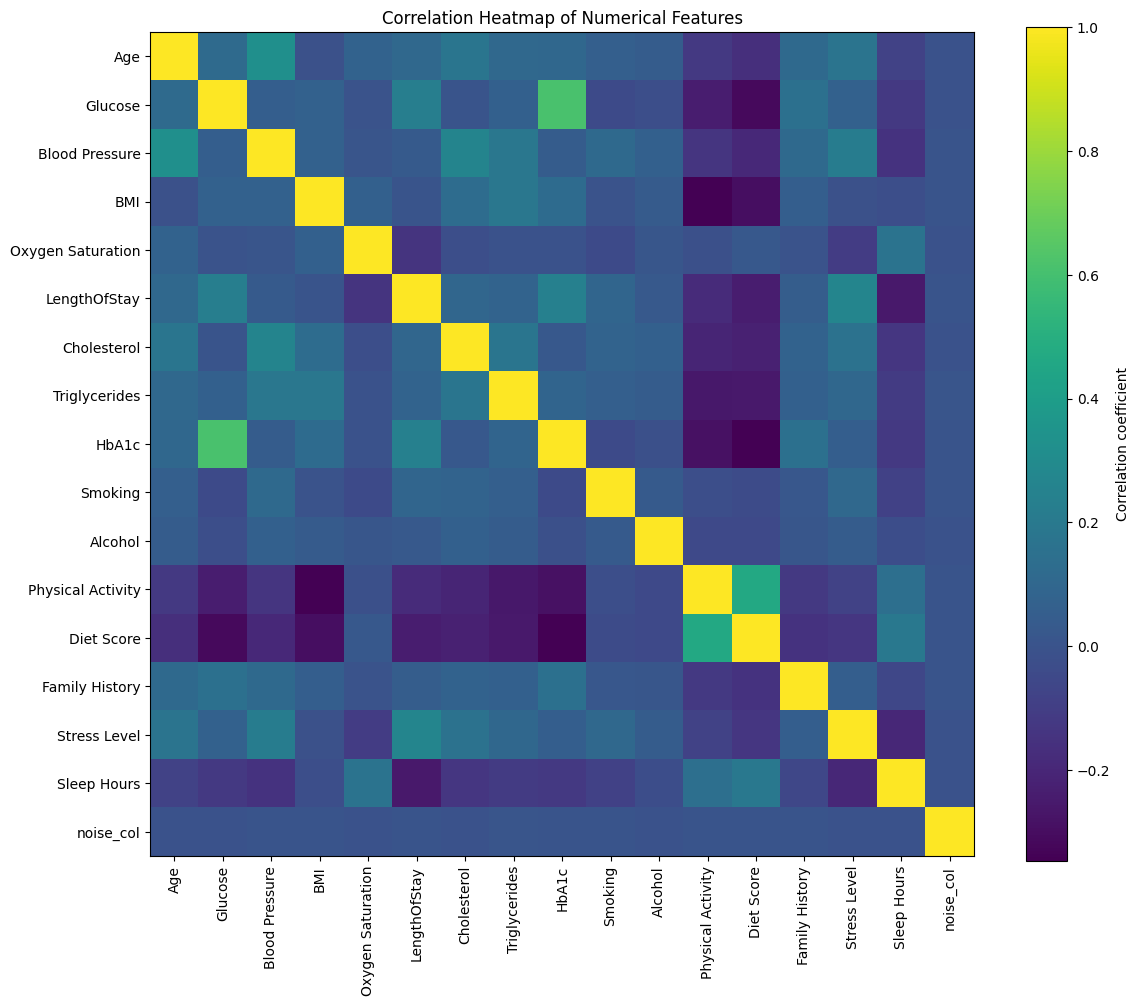

In [ ]:
plt.figure(figsize=(12, 10))

plt.imshow(corr_matrix)
plt.colorbar(label='Correlation coefficient')

plt.xticks(
    ticks=np.arange(len(num_cols)),
    labels=num_cols,
    rotation=90
)
plt.yticks(
    ticks=np.arange(len(num_cols)),
    labels=num_cols
)

plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

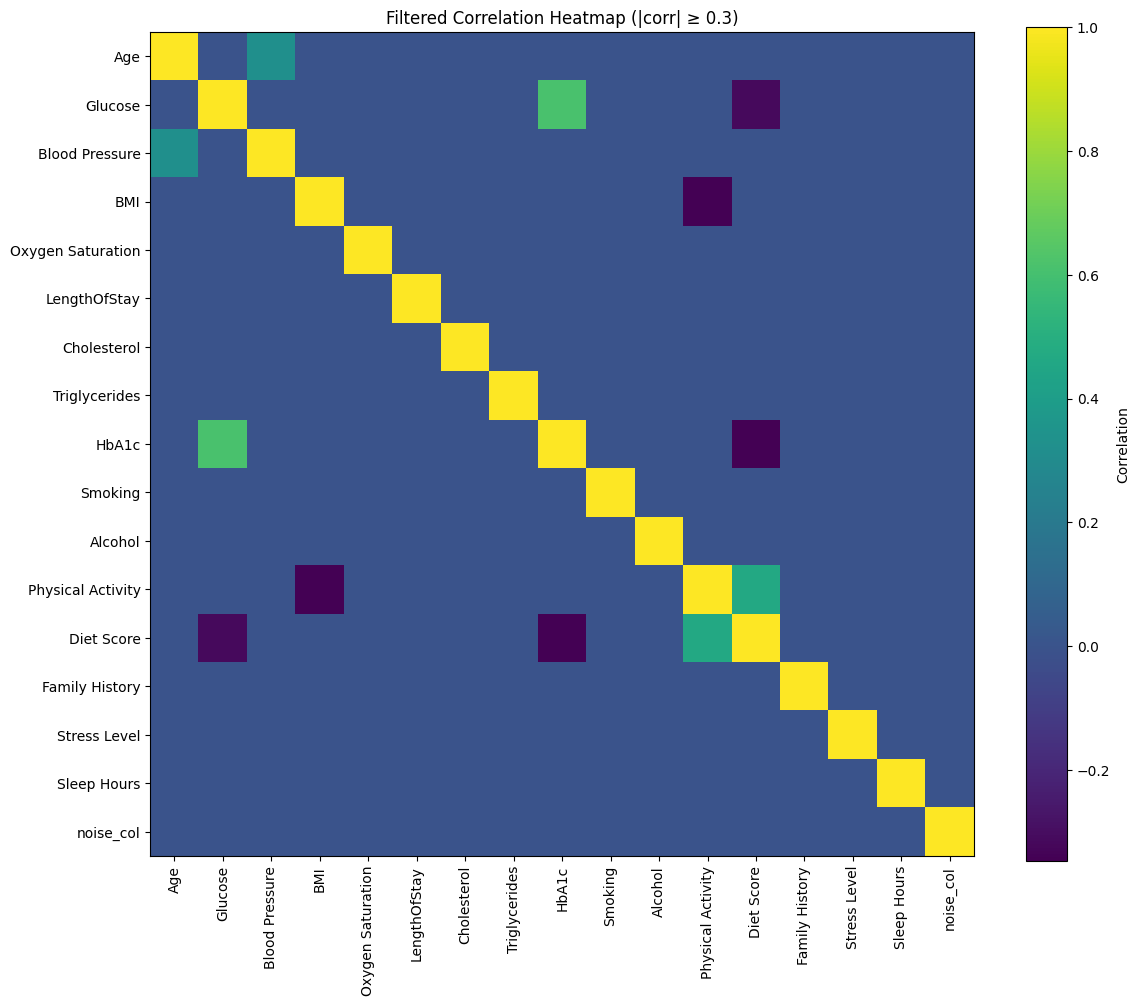

In [ ]:
corr_filtered = corr_matrix.copy()
corr_filtered[abs(corr_filtered) < 0.3] = 0

plt.figure(figsize=(12,10))
plt.imshow(corr_filtered)
plt.colorbar(label='Correlation')
plt.xticks(range(len(num_cols)), num_cols, rotation=90)
plt.yticks(range(len(num_cols)), num_cols)
plt.title('Filtered Correlation Heatmap (|corr| ≥ 0.3)')
plt.tight_layout()
plt.show()

The correlation heatmap shows that most numerical features have weak correlations with each other, indicating low multicollinearity.
Stronger correlations are observed between medically related variables such as Glucose and HbA1c, as well as lifestyle-related features like physical activity and diet score.

##**EDA for categorical columns**

###**Catagorical Columns**

In [ ]:
print("Categorical Columns:\n")
print(list(cat_cols))


Categorical Columns:

['Gender', 'Medical Condition', 'random_notes']


###**Catagorical Columns' Data**

In [ ]:
for col in cat_cols:
    print(f"\nTop categories in '{col}':")
    print(df[col].value_counts().head())


Top categories in 'Gender':
Gender
Female    12865
Male      12635
Name: count, dtype: int64

Top categories in 'Medical Condition':
Medical Condition
Hypertension    7120
Diabetes        6417
Obesity         3857
Healthy         3039
Asthma          2037
Name: count, dtype: int64

Top categories in 'random_notes':
random_notes
###      7575
??       7547
ipsum    7476
lorem    7402
Name: count, dtype: int64


###**Percentage of distribution of data in catagorical columns**

In [ ]:
for col in cat_cols:
    print(f"\nPercentage distribution for '{col}':\n")
    print((df[col].value_counts(normalize=True) * 100).round(2))


Percentage distribution for 'Gender':

Gender
Female    50.45
Male      49.55
Name: proportion, dtype: float64

Percentage distribution for 'Medical Condition':

Medical Condition
Hypertension    27.92
Diabetes        25.16
Obesity         15.13
Healthy         11.92
Asthma           7.99
Arthritis        7.04
Cancer           4.84
Name: proportion, dtype: float64

Percentage distribution for 'random_notes':

random_notes
###      25.25
??       25.16
ipsum    24.92
lorem    24.67
Name: proportion, dtype: float64


###**Unique values in each catagorical column**

In [ ]:
for col in cat_cols:
    print(col, "→", df[col].nunique(), "unique values")

Gender → 2 unique values
Medical Condition → 7 unique values
random_notes → 4 unique values


###**Count Plot for catagorical columns**

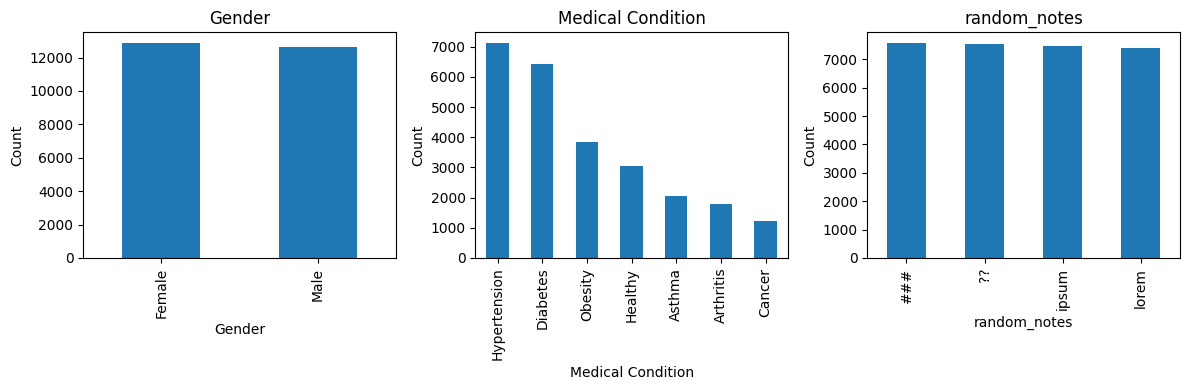

In [ ]:
plt.figure(figsize=(12, 4))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(1, 3, i)
    df[col].value_counts().plot(kind='bar')
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

###**Missing Values in catagorical columns**

In [ ]:
print("Missing Values in Categorical Columns:\n")
print(df[cat_cols].isnull().sum())

Missing Values in Categorical Columns:

Gender               4500
Medical Condition    4500
random_notes            0
dtype: int64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                25500 non-null  float64
 1   Gender             25500 non-null  object 
 2   Medical Condition  25500 non-null  object 
 3   Glucose            25500 non-null  float64
 4   Blood Pressure     25500 non-null  float64
 5   BMI                30000 non-null  float64
 6   Oxygen Saturation  30000 non-null  float64
 7   LengthOfStay       30000 non-null  int64  
 8   Cholesterol        30000 non-null  float64
 9   Triglycerides      30000 non-null  float64
 10  HbA1c              30000 non-null  float64
 11  Smoking            30000 non-null  int64  
 12  Alcohol            30000 non-null  int64  
 13  Physical Activity  30000 non-null  float64
 14  Diet Score         30000 non-null  float64
 15  Family History     30000 non-null  int64  
 16  Stress Level       300

## **Data Cleaning**

### **Drop Unnecessary Columns**

In [ ]:
df=df.drop(columns=['random_notes', 'noise_col'])

num_cols = df.select_dtypes(np.number).columns
cat_cols = df.select_dtypes('object').columns

Random Notes column didn't have any usefull information same as noise col so we dropped it

### **Remove Duplicates**

In [ ]:
df = df.drop_duplicates()

###**Spliting**

In [ ]:
df = df.dropna(subset=['Medical Condition'])

we drop na in medical condition (Target) so we can split the data

In [ ]:
X = df.drop('Medical Condition', axis=1)
y = df['Medical Condition']

our target variable is Medical Condition

In [ ]:
df['Medical Condition'].value_counts()

,count
Medical Condition,
Hypertension,7120
Diabetes,6417
Obesity,3857
Healthy,3039
Asthma,2037
Arthritis,1796
Cancer,1234


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.1,
    random_state=42,
    stratify=y
)

we split with 90/10 because the data is big and we need the model to trian on larger data

##**Feature Engineering**

###**Making Age group feature**

In [ ]:
x_train['Age_Group'] = pd.cut(
    x_train['Age'],
    bins=[0, 30, 45, 60, 100],
    labels=['Young', 'Adult', 'Middle_Age', 'Senior']
)

x_test['Age_Group'] = pd.cut(
    x_test['Age'],
    bins=[0, 30, 45, 60, 100],
    labels=['Young', 'Adult', 'Middle_Age', 'Senior'])


###**Making Health Risk Index feature**

In [ ]:
x_train['Health_Risk_Index'] = (
    x_train['BMI'] +
    x_train['Cholesterol'] / 100 +
    x_train['Glucose'] / 100 +
    x_train['Stress Level']
)

x_test['Health_Risk_Index'] = (
    x_test['BMI'] +
    x_test['Cholesterol'] / 100 +
    x_test['Glucose'] / 100 +
    x_test['Stress Level']
)

###**Making Lifestyle Score feature**


In [ ]:
x_train['Lifestyle_Score'] = (
    x_train['Physical Activity'] +
    x_train['Diet Score'] -
    x_train['Smoking'] -
    x_train['Alcohol']
)

x_test['Lifestyle_Score'] = (
    x_test['Physical Activity'] +
    x_test['Diet Score'] -
    x_test['Smoking'] -
    x_test['Alcohol']
)

##**Encoding**

###**Encoding catagrocial features using Label Encoder**

In [ ]:
cat_cols_x=x_train.select_dtypes(include="object").columns

In [ ]:
cat_cols_x

Index(['Gender'], dtype='object')

In [ ]:
le = LabelEncoder()

In [ ]:
# Using LabelEncoder for target variable
y_train[:] = le.fit_transform(y_train)

In [ ]:
y_test[:]  = le.transform(y_test)

In [ ]:
for col in cat_cols_x:
  x_train[col]=le.fit_transform(x_train[col])
  x_test[col]=le.transform(x_test[col])

###**Encoding Age Group using one-hot encoder**

In [ ]:
ohe_col=["Age_Group"]

In [ ]:
x_train=pd.get_dummies(data=x_train,columns=ohe_col)

In [ ]:
x_test=pd.get_dummies(data=x_test,columns=ohe_col)

## **Handle Missing Values**

### **Missing Data**

In [ ]:
x_train.isnull().sum()

,0
Age,3457
Gender,0
Glucose,3372
Blood Pressure,3417
BMI,0
Oxygen Saturation,0
LengthOfStay,0
Cholesterol,0
Triglycerides,0
HbA1c,0


In [ ]:
def nulls_summary_table(df):
    null_values = pd.DataFrame(df.isnull().sum())
    null_values[1] = null_values[0]/len(df)
    null_values.columns = ['null_count','null_pct']
    return null_values

nulls_summary_table(x_train)

,null_count,null_pct
Age,3457,0.150632
Gender,0,0.000000
Glucose,3372,0.146928
Blood Pressure,3417,0.148889
BMI,0,0.000000
Oxygen Saturation,0,0.000000
LengthOfStay,0,0.000000
Cholesterol,0,0.000000
Triglycerides,0,0.000000
HbA1c,0,0.000000


### **Normalize or standardize numerical features**

In [ ]:
num_cols = [
    'Age',
    'Glucose',
    'Blood Pressure',
    'BMI',
    'Oxygen Saturation',
    'LengthOfStay',
    'Cholesterol',
    'Triglycerides',
    'HbA1c',
    'Smoking',
    'Alcohol',
    'Physical Activity',
    'Diet Score',
    'Family History',
    'Stress Level',
    'Sleep Hours',
    'Health_Risk_Index',
    "Lifestyle_Score"

]
cat_cols=["Gender"]

In [ ]:
# Using standard scalar
scaler = StandardScaler()
x_train[num_cols] = scaler.fit_transform(x_train[num_cols])
x_test[num_cols]  = scaler.transform(x_test[num_cols])

We scaled the data before imputation because we are using KNN imputer so we need to scale the data first

In [ ]:
miss_col_num=["Age","Glucose","Blood Pressure","Health_Risk_Index"]

### **Imputation with KNN Imputer for numeric features**

In [ ]:
imputer = KNNImputer(n_neighbors=5)
x_train[miss_col_num] = imputer.fit_transform(x_train[miss_col_num])
x_test[miss_col_num] = imputer.transform(x_test[miss_col_num])

###**Imputation for catagorical features with simple imputer (Mode)**

In [ ]:
# using imputation by mode  for categorical columnns
cat_imputer = SimpleImputer(strategy='most_frequent')

In [ ]:
x_train[cat_cols]=cat_imputer.fit_transform(x_train[cat_cols])
x_test[cat_cols]=cat_imputer.transform(x_test[cat_cols])

### **Checking for null after imputation**

In [ ]:
np.isnan(x_train).sum()
np.isnan(x_test).sum()

,0
Age,0
Gender,0
Glucose,0
Blood Pressure,0
BMI,0
Oxygen Saturation,0
LengthOfStay,0
Cholesterol,0
Triglycerides,0
HbA1c,0


### **Handle Outliers with interquartile method**

In [ ]:
def remove_outliers_iqr(df, cols):
    for col in cols:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        df = df[(df[col] >= lower) & (df[col] <= upper)]
    return df

In [ ]:
x_train = remove_outliers_iqr(x_train, num_cols)

In [ ]:
y_train = y_train.loc[x_train.index]

### **Boxplot for numerical columns after handling outliers**

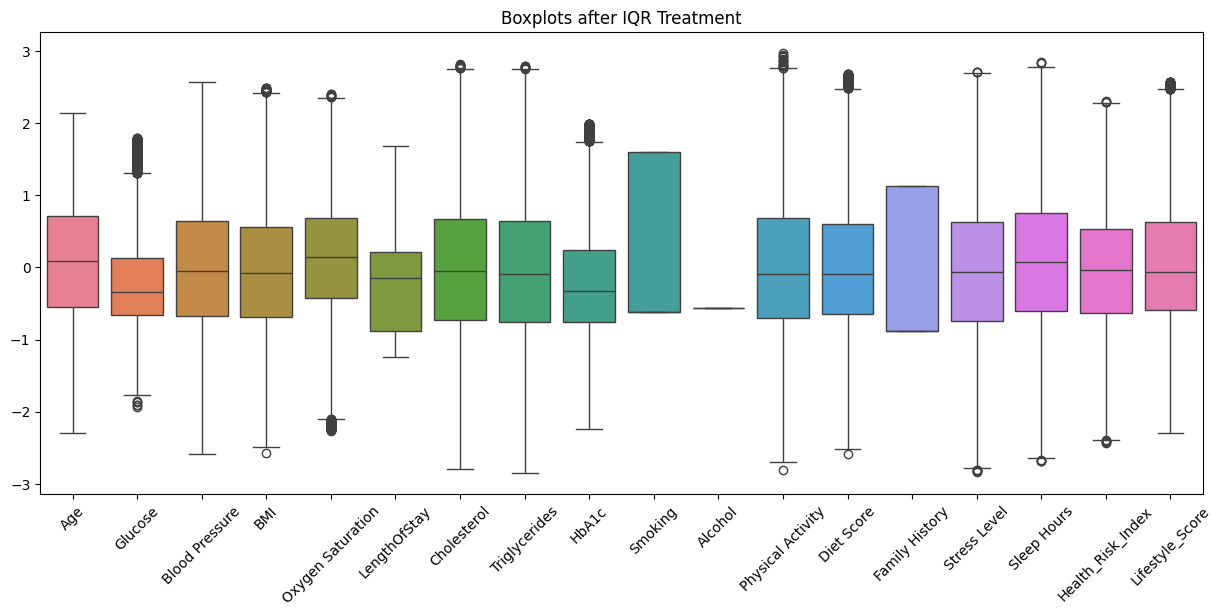

In [ ]:
plt.figure(figsize=(15,6))
sns.boxplot(data=x_train[num_cols])
plt.xticks(rotation=45)
plt.title("Boxplots after IQR Treatment")
plt.show()

###**Handeling Imbalanced Data Using SMOTE**

<Axes: xlabel='Medical Condition'>

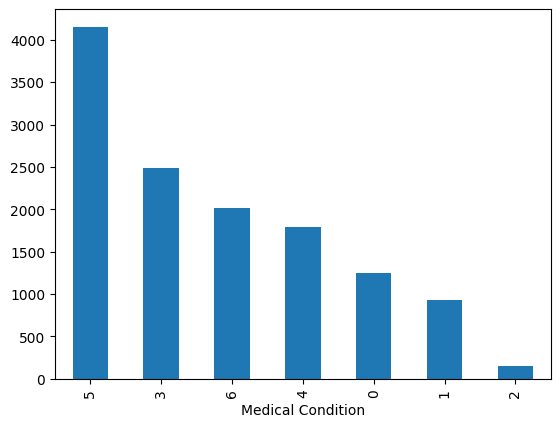

In [ ]:
y_train.value_counts().plot(kind="bar")

In [ ]:
y_train = y_train.astype(int)

In [ ]:
smote = SMOTE(random_state=42)

x_train, y_train = smote.fit_resample(
    x_train, y_train
)

<Axes: xlabel='Medical Condition'>

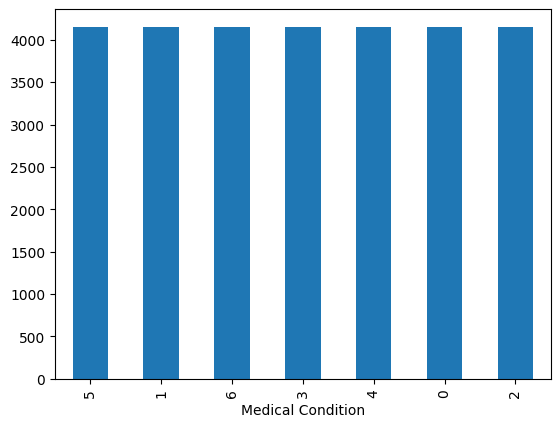

In [ ]:
y_train.value_counts().plot(kind="bar")

##**Feature Selection**

###**Feature Selection Using Statistical Based Method**

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=15)

X_train_selected = selector.fit_transform(x_train, y_train)
X_test_selected  = selector.transform(x_test)

selected_features = x_train.columns[selector.get_support()]
selected_features

Index(['Age', 'Glucose', 'Blood Pressure', 'BMI', 'LengthOfStay',
       'Cholesterol', 'Triglycerides', 'HbA1c', 'Physical Activity',
       'Diet Score', 'Stress Level', 'Sleep Hours', 'Health_Risk_Index',
       'Lifestyle_Score', 'Age_Group_Senior'],
      dtype='object')

###**Feature Selection Using Model Based Method (RBF)**

In [ ]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(x_train, y_train)

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)

In [ ]:
imp_df = pd.DataFrame({
    "feature": x_train.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

imp_df

,feature,importance
6,LengthOfStay,0.190211
9,HbA1c,0.093819
18,Lifestyle_Score,0.091057
2,Glucose,0.073127
12,Physical Activity,0.065942
0,Age,0.064238
3,Blood Pressure,0.058972
4,BMI,0.049373
13,Diet Score,0.046262
16,Sleep Hours,0.044235


In [ ]:
x_train=x_train.drop(["Age_Group_Senior","Age_Group_Adult","Age_Group_Young","Smoking","Family History","Gender","Age_Group_Middle_Age","Alcohol"],axis=1)
x_test=x_test.drop(["Age_Group_Senior","Age_Group_Adult","Age_Group_Young","Smoking","Family History","Gender","Age_Group_Middle_Age","Alcohol"],axis=1)

As we can see from features importance we can safely remove the following features as they don't affect the model at all : Alcohol, all age groups , gender , family history and smoking

## **Modeling & Evaluation**

###**Using Logistic Regression Model**

In [ ]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(x_train, y_train)

y_pred_log = log_model.predict(x_test)

###**Cross Validation of Logistic Regression**

In [ ]:
cv_scores = cross_val_score(
    log_model,
    x_train,
    y_train,
    cv=5,
    scoring='recall_macro'
)

cv_scores.mean()

np.float64(0.896120386652334)

In [ ]:
cv_scores

array([0.87912061, 0.88566188, 0.89544604, 0.91070688, 0.90966652])

###**Accuracy and classification report for logistic regression**

In [ ]:
y_test=y_test.astype("int64")

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Accuracy: 0.8898039215686274
              precision    recall  f1-score   support

           0       0.62      0.76      0.68       179
           1       0.83      0.93      0.88       204
           2       0.88      0.99      0.93       123
           3       0.95      0.93      0.94       642
           4       0.99      1.00      0.99       304
           5       0.91      0.82      0.86       712
           6       0.88      0.88      0.88       386

    accuracy                           0.89      2550
   macro avg       0.86      0.90      0.88      2550
weighted avg       0.90      0.89      0.89      2550



###**Using RandomForest Model**

In [ ]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(x_train, y_train)

y_pred_rf = rf_model.predict(x_test)

###**Accuracy and classification report for random forest**

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.9054901960784314
              precision    recall  f1-score   support

           0       0.73      0.72      0.72       179
           1       0.87      0.91      0.89       204
           2       0.95      0.93      0.94       123
           3       0.94      0.95      0.94       642
           4       0.99      0.99      0.99       304
           5       0.90      0.88      0.89       712
           6       0.89      0.89      0.89       386

    accuracy                           0.91      2550
   macro avg       0.89      0.90      0.90      2550
weighted avg       0.91      0.91      0.91      2550



###**Using GradientBoosting Model**

In [ ]:
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(x_train, y_train)

y_pred_gb = gb_model.predict(x_test)

###**Cross Validation of GradientBoosting**

In [ ]:
cv_scores_gb=cross_val_score(gb_model, x_train, y_train,
                cv=5, scoring='recall_macro')
cv_scores_gb

array([0.90319359, 0.91781567, 0.93310467, 0.93909439, 0.94304542])

###**Accuracy and classification report for gradientboosting**

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

Accuracy: 0.908235294117647
              precision    recall  f1-score   support

           0       0.67      0.77      0.72       179
           1       0.88      0.94      0.91       204
           2       0.95      0.98      0.96       123
           3       0.94      0.94      0.94       642
           4       0.99      0.99      0.99       304
           5       0.92      0.86      0.89       712
           6       0.90      0.91      0.90       386

    accuracy                           0.91      2550
   macro avg       0.89      0.91      0.90      2550
weighted avg       0.91      0.91      0.91      2550



##**HyperParameter Tunning Using GridSearch for randomforest**

In [ ]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

grid_rf.fit(x_train, y_train)

best_rf = grid_rf.best_estimator_

###**Accuracy and classification report for random forest after gridsearch**

In [ ]:
y_pred_best_rf = best_rf.predict(x_test)

print("Best Parameters:", grid_rf.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred_best_rf))
print(classification_report(y_test, y_pred_best_rf))

Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Accuracy: 0.9043137254901961
              precision    recall  f1-score   support

           0       0.74      0.70      0.72       179
           1       0.87      0.91      0.89       204
           2       0.95      0.92      0.93       123
           3       0.93      0.95      0.94       642
           4       0.99      0.99      0.99       304
           5       0.90      0.88      0.89       712
           6       0.88      0.90      0.89       386

    accuracy                           0.90      2550
   macro avg       0.89      0.89      0.89      2550
weighted avg       0.90      0.90      0.90      2550



###**Using Ensemble Method (Voting)**

In [ ]:
ensemble_model = VotingClassifier(
    estimators=[
        ('lr', log_model),
        ('rf', best_rf),
        ('gb', gb_model)
    ],
    voting='hard'
)

ensemble_model.fit(x_train, y_train)

y_pred_ensemble = ensemble_model.predict(x_test)

###**Cross Validation of Ensemble Model**

In [ ]:
cross_val_score_ensemble=cross_val_score(
    ensemble_model,
    x_train,
    y_train,
    cv=5,
    scoring='recall_macro'
)


In [ ]:
cross_val_score_ensemble

array([0.91729331, 0.9240067 , 0.9346529 , 0.95062064, 0.94769092])

###**Accuracy and classification report for Voting ensemble model**

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_ensemble))
print(classification_report(y_test, y_pred_ensemble))

Accuracy: 0.9113725490196078
              precision    recall  f1-score   support

           0       0.71      0.77      0.73       179
           1       0.86      0.94      0.90       204
           2       0.95      0.99      0.97       123
           3       0.95      0.95      0.95       642
           4       0.99      0.99      0.99       304
           5       0.92      0.86      0.89       712
           6       0.89      0.90      0.90       386

    accuracy                           0.91      2550
   macro avg       0.90      0.92      0.90      2550
weighted avg       0.91      0.91      0.91      2550



##**Comparing Each Model and choosing best one**

In [ ]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1_macro": f1_score(y_test, y_pred, average='macro'),
        "Recall_macro": recall_score(y_test, y_pred, average='macro'),
        "Precision_macro": precision_score(y_test, y_pred, average='macro')
    }

In [ ]:
results = {}

results['Logistic Regression'] = evaluate_model(
    log_model, x_test, y_test
)

results['Random Forest (Tuned)'] = evaluate_model(
    best_rf, x_test, y_test
)

results['Gradient Boosting'] = evaluate_model(
    gb_model, x_test, y_test
)

results['Ensemble'] = evaluate_model(
    ensemble_model, x_test, y_test
)

In [ ]:
results_df = pd.DataFrame(results).T
results_df

,Accuracy,F1_macro,Recall_macro,Precision_macro
Logistic Regression,0.889804,0.880220,0.900856,0.864264
Random Forest (Tuned),0.904314,0.892947,0.892469,0.893844
Gradient Boosting,0.908235,0.901394,0.912261,0.892124
Ensemble,0.911373,0.904505,0.915076,0.895222


We will choose the model based on mainly the recall because we work on classification data with imbalance and also medical data so we focus on recall more because we want to minimize the false negative and make sure medical conditions are correctly identified

so given the previous table the best model to choose is: Voting Ensemble Model

##**Learning Curve**

###**Learning Curve of ensemble model**

In [ ]:
model = ensemble_model

In [ ]:
train_sizes, train_scores, val_scores = learning_curve(
    model,
    x_train,
    y_train,
    cv=5,
    scoring='recall_macro',
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

In [ ]:
train_mean = np.mean(train_scores, axis=1)
train_std  = np.std(train_scores, axis=1)

val_mean = np.mean(val_scores, axis=1)
val_std  = np.std(val_scores, axis=1)

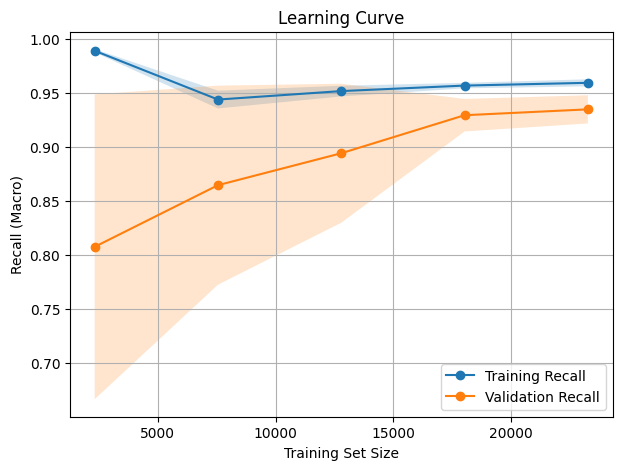

In [ ]:
plt.figure(figsize=(7,5))

plt.plot(train_sizes, train_mean, marker='o', label='Training Recall')
plt.plot(train_sizes, val_mean, marker='o', label='Validation Recall')

plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.2
)

plt.fill_between(
    train_sizes,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.2
)

plt.xlabel('Training Set Size')
plt.ylabel('Recall (Macro)')
plt.title('Learning Curve')
plt.legend()
plt.grid(True)
plt.show()


The learning curve shows a small gap between training and validation recall, indicating good generalization and minimal overfitting.
As the training size increases, the validation performance improves and stabilizes, suggesting that the model has learned meaningful patterns from the data

##**ROC**

In [ ]:
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

In [ ]:
y_score = best_rf.predict_proba(x_test)

In [ ]:
fpr = {}
tpr = {}
roc_auc = {}

for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

In [ ]:
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(len(classes))]))

mean_tpr = np.zeros_like(all_fpr)
for i in range(len(classes)):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= len(classes)

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])


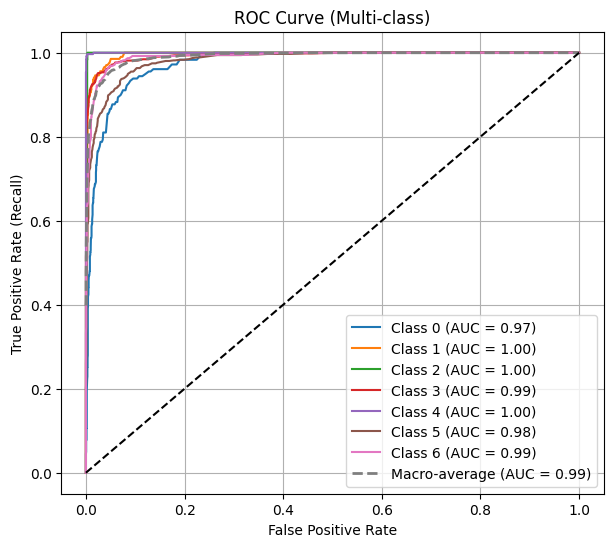

In [ ]:
plt.figure(figsize=(7,6))

for i in range(len(classes)):
    plt.plot(
        fpr[i],
        tpr[i],
        label=f'Class {i} (AUC = {roc_auc[i]:.2f})'
    )

plt.plot(
    fpr["macro"],
    tpr["macro"],
    linestyle='--',
    label=f'Macro-average (AUC = {roc_auc["macro"]:.2f})',
    linewidth=2
)

plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve (Multi-class)')
plt.legend()
plt.grid(True)
plt.show()


The ROC curves show near-perfect AUC values for all classes, indicating a strong discriminative ability of the model.
This performance is attributed to effective feature engineering, class balancing, and the use of ensemble-based models.

##**Deployment**

In [ ]:
joblib.dump(model, "model1.pkl")

['model1.pkl']